In [278]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [279]:
# Read the csv file
df = pd.read_csv("data/customer_booking.csv", encoding="ISO-8859-1")

In [280]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


# Sales Channel

In [281]:
internet = df.sales_channel.value_counts().values[0] / df.sales_channel.count() * 100
mobile = df.sales_channel.value_counts().values[1] / df.sales_channel.count() * 100

In [282]:
print(f"Numbers of customers who booked through the internet: {internet:.2f}%")
print(f"Numbers of customers who booked through mobile: {mobile:.2f}%")

Numbers of customers who booked through the internet: 88.76%
Numbers of customers who booked through mobile: 11.24%


# Trip Type

In [283]:
round_trip = df.trip_type.value_counts().values[0] / df.trip_type.count() * 100
one_way_trip = df.trip_type.value_counts().values[1] / df.trip_type.count() * 100
circle_trip = df.trip_type.value_counts().values[2] / df.trip_type.count() * 100

In [284]:
print(f"Numbers of customers who booked round trip: {round_trip:.2f}%")
print(f"Numbers of customers who booked one way trip: {one_way_trip:.2f}%")
print(f"Numbers of customers who booked circle trip: {circle_trip:.2f}%")

Numbers of customers who booked round trip: 98.99%
Numbers of customers who booked one way trip: 0.77%
Numbers of customers who booked circle trip: 0.23%


# Purchase Lead

<Axes: xlabel='purchase_lead', ylabel='Count'>

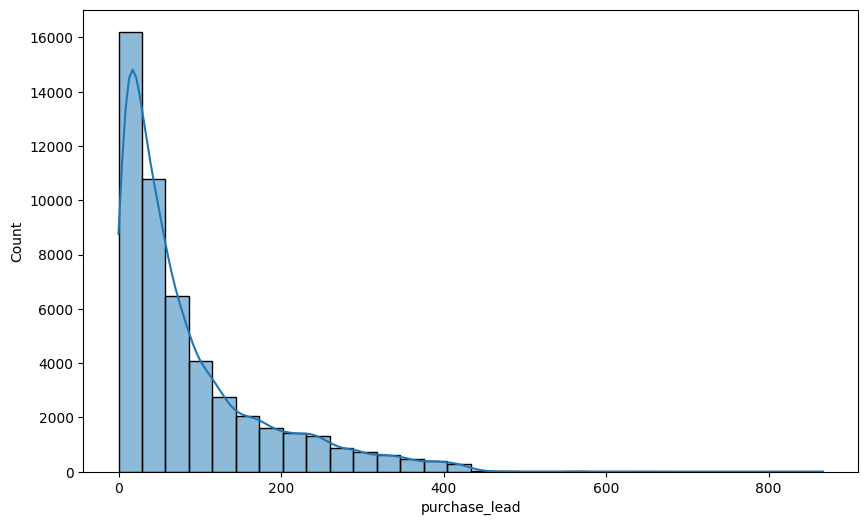

In [285]:
plt.figure(figsize=(10, 6))
sns.histplot(df.purchase_lead, bins=30, kde=True)

Some bookings have a purchase lead exceeding 2 years, which is not a normal booking behavior. So we will treat them as outliers because they are rare and they can affect the the results of the predictive model.

In [286]:
(df.purchase_lead > 365).value_counts()

purchase_lead
False    49162
True       838
Name: count, dtype: int64

If we assume that no customer can book in advance of more than one year, we will remove all entries with purchase lead more than 365 days.

In [287]:
df[df.purchase_lead > 365].booking_complete.value_counts()

booking_complete
0    722
1    116
Name: count, dtype: int64

In [288]:
df = df[df.purchase_lead <= 365]

# Length of Stay

<Axes: xlabel='length_of_stay', ylabel='Count'>

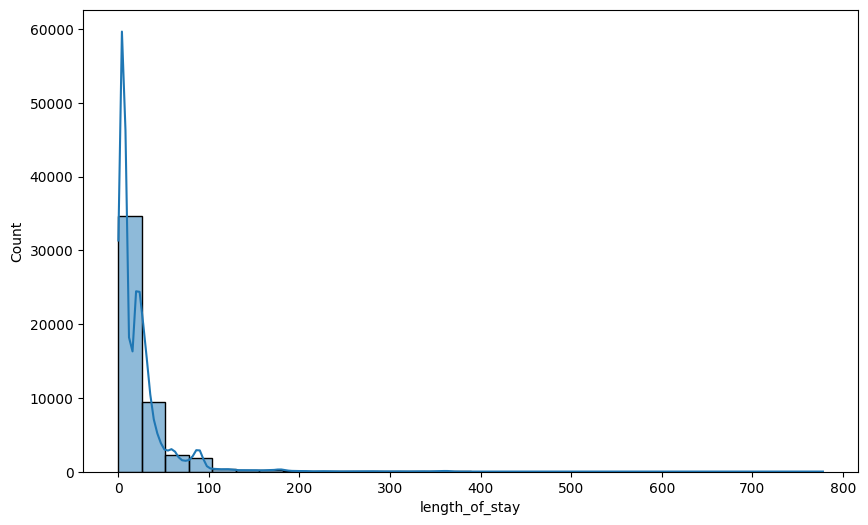

In [289]:
plt.figure(figsize=(10, 6))
sns.histplot(df.length_of_stay, bins=30, kde=True)

In [290]:
(df.length_of_stay > 400).value_counts()

length_of_stay
False    49146
True        16
Name: count, dtype: int64

We need more business knowledge to decide whether bookings with more than 400 days of stay should be removed, as there could be several reasons for such cases. For now, we will focus only on bookings with a length of stay of less than 400 days.

In [291]:
df = df[df.purchase_lead <= 400]

# Flight Day

In [292]:
mapping = {
    "Mon" : 0,
    "Tue" : 1,
    "Wed" : 2,
    "Thu" : 3,
    "Fri" : 4,
    "Sat" : 5,
    "Sun" : 6
}

In [293]:
df.flight_day = df.flight_day.map(mapping)

In [294]:
df.flight_day.value_counts()

flight_day
0    7901
2    7600
1    7552
3    7364
4    6707
6    6318
5    5720
Name: count, dtype: int64

# Booking Complete

In [295]:
Successful_bookings = df.booking_complete.value_counts().values[1] / df.booking_complete.count() * 100
unsuccessful_bookings = df.booking_complete.value_counts().values[0] / df.booking_complete.count() * 100
print(f"Numbers of successful bookings: {Successful_bookings:.2f}%")
print(f"Numbers of unsuccessful bookings: {unsuccessful_bookings:.2f}%")

Numbers of successful bookings: 14.97%
Numbers of unsuccessful bookings: 85.03%


# Encoding

In [296]:
nominal_cols = ["sales_channel", "trip_type"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [297]:
df['route_encoded'] = df['route'].map(df['route'].value_counts())

Encode the route column using frequency encoding: map each route to its count of occurrences in the dataset
This transforms categorical route data into numerical values based on popularity, helping the model learn demand patterns

In [298]:
df.shape

(49162, 16)

In [299]:
df.columns

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'flight_day', 'route', 'booking_origin', 'wants_extra_baggage',
       'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration',
       'booking_complete', 'sales_channel_Mobile', 'trip_type_OneWay',
       'trip_type_RoundTrip', 'route_encoded'],
      dtype='str')

In [300]:
df_final = df.drop(columns=["booking_origin","route"])

In [301]:
df_final

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,sales_channel_Mobile,trip_type_OneWay,trip_type_RoundTrip,route_encoded
0,2,262,19,7,5,1,0,0,5.52,0,False,False,True,18
1,1,112,20,3,5,0,0,0,5.52,0,False,False,True,18
2,2,243,22,17,2,1,1,0,5.52,0,False,False,True,18
3,1,96,31,4,5,0,0,1,5.52,0,False,False,True,18
4,2,68,22,15,2,1,0,1,5.52,0,False,False,True,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,27,6,9,5,1,0,1,5.62,0,False,False,True,220
49996,1,111,6,4,6,0,0,0,5.62,0,False,False,True,220
49997,1,24,6,22,5,0,0,1,5.62,0,False,False,True,220
49998,1,15,6,11,0,1,0,1,5.62,0,False,False,True,220


# Normalizing the values


In [302]:
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)

# Splitting Train and Test data

In [303]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [304]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score


# Random Forest Classifier


In [305]:
model = RandomForestClassifier(max_depth =50 , min_samples_split=5,random_state=0)

In [306]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

# Checking Training accuracy


In [307]:
y_pred_train = model.predict(X_train)

In [308]:
#f1 score for training data
f1 = round(f1_score(y_train, y_pred_train),2) 

print("f1-score for training data is", f1)

f1-score for training data is 0.99


#accuracy score for training data
acc = round(accuracy_score(y_train, y_pred_train),2) 

print("Accuracy for training data is", acc)

#precision score for training data
pre = round(precision_score(y_train, y_pred_train),2) 

print("precision for training data is", pre)

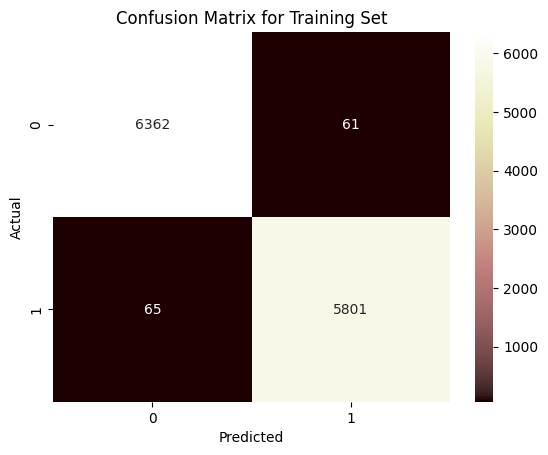

In [309]:
cm = confusion_matrix(y_train, y_pred_train, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='pink')
plt.title('Confusion Matrix for Training Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Checking Testing accuracy

In [310]:
y_pred_test = model.predict(X_test)

In [311]:
#f1 score for testing data
f1 = round(f1_score(y_test, y_pred_test),2) 

print("f1-score for testing data is", f1)

f1-score for testing data is 0.65


In [312]:
#accuracy score for testing data
acc = round(accuracy_score(y_test, y_pred_test),2) 

print("Accuracy for testing data is", acc)

Accuracy for testing data is 0.66


In [313]:
#precision score for testing data
pre = round(precision_score(y_test, y_pred_test),2) 

print("precision for testing data is", pre)

precision for testing data is 0.66


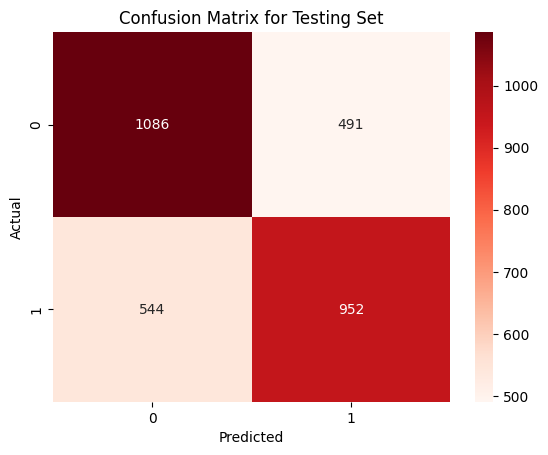

In [314]:
cm = confusion_matrix(y_test, y_pred_test, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix for Testing Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

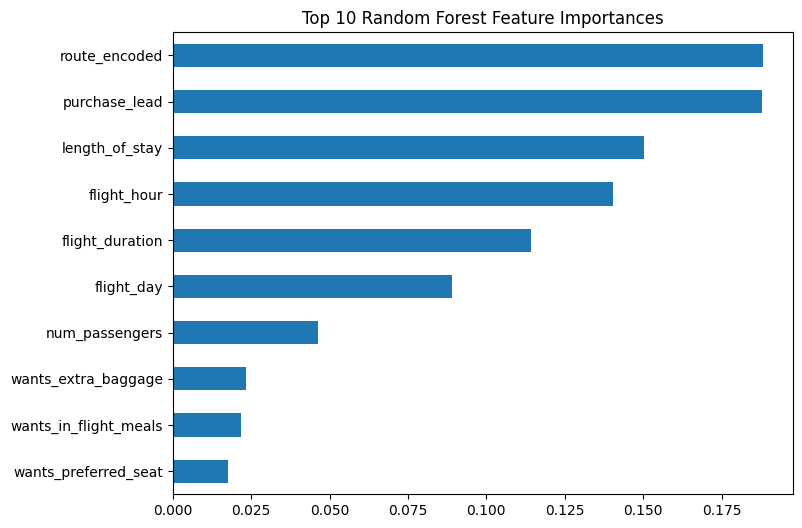

In [315]:
feature_importances = pd.Series(
    model.feature_importances_,
    index=X.columns
)

top_10 = feature_importances.sort_values(ascending=False).head(10)

top_10.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

One reason the F1 score might be low is that the dataset isn’t balanced. There are many more samples of class 0 than class 1. To improve this, we can reduce the number of class 0 samples so that both classes have similar amounts.

# Balancing Dataset

In [316]:
# Create a dataframe having 8000 samples of unsuccessful bookings
df_final_0 = df_final[df_final.booking_complete == 0].sample(n=8000)
# Create a dataframe having all samples of successful bookings
df_final_1 = df_final[df_final.booking_complete == 1]

In [317]:
df_final_0.shape

(8000, 14)

In [318]:
df_final_1

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,sales_channel_Mobile,trip_type_OneWay,trip_type_RoundTrip,route_encoded
82,1,15,31,17,0,0,0,0,8.83,1,False,False,True,2580
86,1,156,19,14,0,1,0,0,8.83,1,False,False,True,2580
94,1,181,87,2,1,1,0,1,8.83,1,False,False,True,2580
109,1,127,17,16,1,1,0,1,8.83,1,True,False,True,2580
122,1,42,17,14,1,0,0,0,8.83,1,False,False,True,2580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49972,1,33,6,6,2,1,1,0,4.67,1,False,False,True,912
49977,2,15,6,16,1,1,1,1,4.67,1,False,False,True,912
49980,4,242,6,9,1,1,0,1,5.00,1,False,False,True,27
49984,2,7,6,4,2,0,0,0,5.62,1,False,False,True,220


In [319]:
# Concatinate the two dataframes to create a balanced dataset
df_final_new = pd.concat([df_final_0, df_final_1], axis=0)

In [320]:
df_final_new.shape

(15362, 14)

In [321]:
# Shuffle the dataframe to mix the successful and unsuccessful bookings
df_final_new = df_final_new.sample(frac=1).reset_index(drop=True)

In [322]:
X = df_final_new.drop(columns=["booking_complete"])
y = df_final_new["booking_complete"]

In [323]:
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)

In [324]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [325]:
model = RandomForestClassifier(max_depth =50 , min_samples_split=5,random_state=0)

In [326]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [327]:
y_pred_train = model.predict(X_train)


In [328]:
#f1 score for training data
f1 = round(f1_score(y_train, y_pred_train),2) 
print("f1-score for training data is", f1)

f1-score for training data is 0.99


In [329]:
#accuracy score for training data
acc = round(accuracy_score(y_train, y_pred_train),2) 
print("Accuracy for training data is", acc)

Accuracy for training data is 0.99


In [330]:
#precision score for training data
pre = round(precision_score(y_train, y_pred_train),2) 

print("precision for training data is", pre)

precision for training data is 0.99


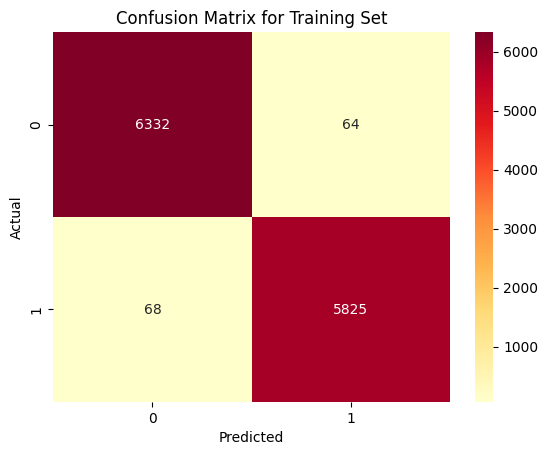

In [331]:
cm = confusion_matrix(y_train, y_pred_train, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Confusion Matrix for Training Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [332]:
y_pred_test = model.predict(X_test)

In [333]:
#f1 score for testing data
f1 = round(f1_score(y_test, y_pred_test),2) 

print("f1-score for testing data is", f1)

f1-score for testing data is 0.63


In [334]:
#accuracy score for testing data
acc = round(accuracy_score(y_test, y_pred_test),2) 

print("Accuracy for testing data is", acc)

Accuracy for testing data is 0.65


In [335]:
#precision score for testing data
pre = round(precision_score(y_test, y_pred_test),2) 

print("precision for testing data is", pre)

precision for testing data is 0.63


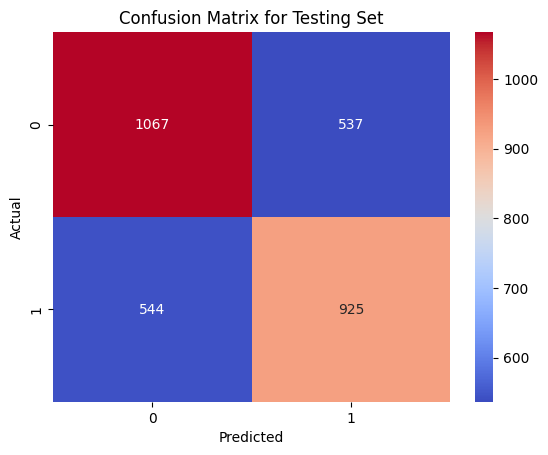

In [336]:
cm = confusion_matrix(y_test, y_pred_test, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix for Testing Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

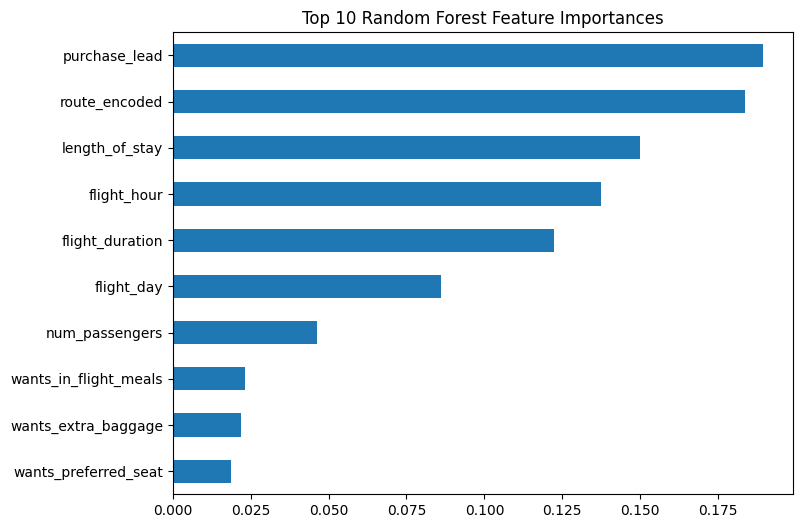

In [337]:
feature_importances = pd.Series(
    model.feature_importances_,
    index=X.columns
)

top_10 = feature_importances.sort_values(ascending=False).head(10)

top_10.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

In [338]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import classification_report, roc_auc_score,recall_score

In [339]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

# Cross Validation

In [340]:
# Cross-Validation (5-fold)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print(f'Cross-Validation AUC Scores: {cv_scores}')
print(f'Mean CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Cross-Validation AUC Scores: [0.70003588 0.69227624 0.71457986 0.70911538 0.69520517]
Mean CV AUC: 0.702 ± 0.008


In [341]:
# Additional CV metrics
cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'])
print(f'CV Accuracy: {cv_results["test_accuracy"].mean():.3f}')
print(f'CV Precision: {cv_results["test_precision"].mean():.3f}')
print(f'CV Recall: {cv_results["test_recall"].mean():.3f}')
print(f'CV F1: {cv_results["test_f1"].mean():.3f}')


CV Accuracy: 0.649
CV Precision: 0.639
CV Recall: 0.615
CV F1: 0.627


In [342]:
# Test Set Evaluation
y_pred = model.predict(X_val)
y_pred_proba =  model.predict_proba(X_val)[:, 1]

print('Test Classification Report:')
print(classification_report(y_val, y_pred))
print(f'Test AUC-ROC: {roc_auc_score(y_val, y_pred_proba):.3f}')
print(f'Test Accuracy: {accuracy_score(y_val, y_pred):.3f}')
print(f'Test Precision: {precision_score(y_val, y_pred):.3f}')
print(f'Test Recall: {recall_score(y_val, y_pred):.3f}')
print(f'Test F1: {f1_score(y_val, y_pred):.3f}')

Test Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1594
           1       0.92      0.92      0.92      1479

    accuracy                           0.92      3073
   macro avg       0.92      0.92      0.92      3073
weighted avg       0.92      0.92      0.92      3073

Test AUC-ROC: 0.974
Test Accuracy: 0.924
Test Precision: 0.922
Test Recall: 0.921
Test F1: 0.921


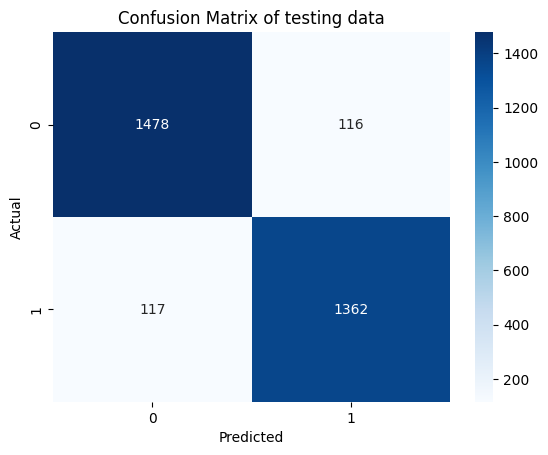

In [343]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix of testing data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

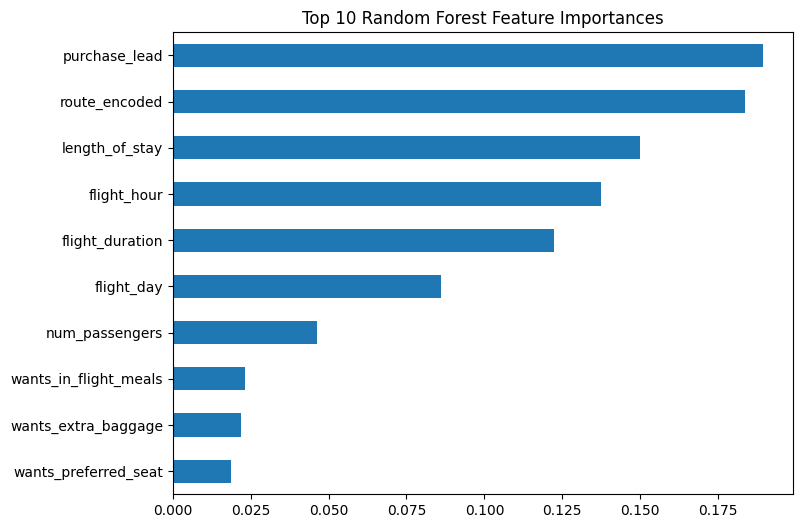

In [344]:
feature_importances = pd.Series(
    model.feature_importances_,
    index=X_val.columns
)

top_10 = feature_importances.sort_values(ascending=False).head(10)

top_10.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 10 Random Forest Feature Importances")
plt.show()